# Table of contents

* **Introduction**
* **Objective**
* **Pipeline Overview**
* **Data dictionary**
* **Approach**
* **Data Loading**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Text Cleaning**
* **Features Engineering**
    * Tokenization and Vocabulary Building
    * Tokenization
    * N-Gram Tokens Sequence Generation
    * Sequences Padding
    * Train and Validation Split
* **Model Training**
    * Model Architecture, Model Building, and Model Training (Keras)
    * Model Architecture
    * Model Validation (Perplexity)
* **Model Evaluation**
    * Perplexity, Rouge-L, Rouge-S, and Rouge-SU
    * Inference Test
* **Conclusion**
* **References**

# Introduction

Text generation is a key task in natural language processing (NLP) that involves generating coherent and contextually relevant text sequences. Transformer models, introduced in the seminal paper "Attention is All You Need" ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)), have revolutionized NLP due to their ability to capture long-range dependencies through self-attention mechanisms. This tutorial demonstrates how to build a Transformer-based model for text generation using the Keras framework in TensorFlow. The "project leverages a dataset of essays to train a model that predicts the next token in a sequence, enabling it to generate text based on given prompts. Key components include data preprocessing, tokenization, Transformer architecture design, model training, and evaluation using metrics like perplexity and ROUGE scores."

# Objective

The objective of this project is to develop a Transformer-based model capable of generating coherent text sequences by predicting the next token given a sequence of preceding tokens. Specifically, the model is trained on a dataset of essays (e.g., from the provided Gemini-Pro-LLM-DAIGT dataset) to learn linguistic patterns and generate text that mimics the style and content of the training data. The project aims to:

Preprocess and tokenize text data to prepare it for model training.
Design and train a Transformer decoder model with self-attention and positional encodings.
Evaluate the model’s performance using perplexity and ROUGE metrics (ROUGE-L, ROUGE-S, ROUGE-SU) to assess generation quality.
Demonstrate text generation capabilities by producing sample outputs from test prompts.

This tutorial serves as an educational tool for understanding Transformer-based text generation and provides a practical implementation for NLP enthusiasts and practitioners.

# Pipeline Overview

The text generation pipeline consists of several stages, each critical to preparing data, training the model, and evaluating its performance:

**Data Loading and Sampling:**

- Load the essay dataset (e.g., from a CSV file containing essay texts).
- Sample a subset (e.g., 2% of the data) for computational efficiency during development.

**Data Visualization and Analysis:**

- Analyze the dataset for null values, sentence lengths, and vocabulary size.
- Visualize frequent words using a word cloud to understand the corpus’s content.

**Data Preprocessing:**

- Clean text by removing punctuation, URLs, HTML tags, and non-ASCII characters.
- Tokenize text into sentences and apply N-gram sequence generation for model input.

**Tokenization and Sequence Preparation:**

- Use Keras Tokenizer to convert text into integer sequences.
- Add special tokens (`<SOS>, <EOS>, <OOV>`) and pad sequences to a uniform length.

**Model Architecture and Training:**

- Build a Transformer decoder model with multi-head self-attention, positional embeddings, and feed-forward networks.
- Train the model using the AdamW optimizer with early stopping and learning rate scheduling.

**Model Evaluation:**

- Evaluate the model on training, validation, and test sets using perplexity.
- Assess generated text quality using ROUGE-L, ROUGE-S, and ROUGE-SU metrics.

**Text Generation:**

- Generate text from test prompts using the trained model and evaluate coherence.

This pipeline ensures a robust approach to text generation, from raw text to meaningful outputs.

# Data dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Variable Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">text</td>
    <td class="tg-7zrl">The essay created by each prompt</td>
    <td class="tg-7zrl">Text/String</td>
  </tr>
  <tr>
    <td class="tg-7zrl">label</td>
    <td class="tg-7zrl">Indicating whether the essay originated from a student (0) or was generated by a Language Model (LLM) (1)</td>
    <td class="tg-7zrl">Numeric/Binary</td>
  </tr>
  <tr>
    <td class="tg-7zrl">prompt_name</td>
    <td class="tg-7zrl">Represents which of the seven prompts was used during generation of an essay</td>
    <td class="tg-7zrl">Categorical/String</td>
  </tr>
  <tr>
    <td class="tg-7zrl">source</td>
    <td class="tg-7zrl">The used model during text generation (gemini_pro)</td>
    <td class="tg-7zrl">Categorical/String</td>
  </tr>
  <tr>
    <td class="tg-7zrl">RDizzl3_seven</td>
    <td class="tg-7zrl">Boolean flag</td>
    <td class="tg-7zrl">Boolean</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/etiennekaiser/gemini-pro-llm-daigt-dataset)**

# Approach

This project details the systematic methodology for utilizing a Transformer Decoder architecture for sequence generation, specifically focusing on next-token prediction to model essay text. The process is divided into three distinct phases: 

**Preprocessing Pipeline Approach**

The preprocessing pipeline systematically transforms raw essay text into a clean, tokenized, and structured format, preparing it for consumption by the Transformer model.

**Text Cleaning**

A comprehensive cleaning step standardizes the input text. This involves converting all text to lowercase and stripping out common noise elements such as punctuation, URLs, HTML tags, and non-ASCII characters. This ensures the text is uniform and free of artifacts that could interfere with tokenization or training.

**Sentence Tokenization**

Essays are segmented into individual sentences using the NLTK library. This breaks the large, continuous text into smaller, manageable units. The cleaning function is applied sentence-by-sentence to maintain high data quality before the numerical conversion begins.

**Tokenization and Vocabulary Building**

The Keras Tokenizer converts these cleaned sentences into numerical sequences. A vocabulary is built from the training data and capped at a specific size (e.g., 5,500 words) to manage model complexity. Special tokens are incorporated to define sequence boundaries and handle rare words:

- $\langle SOS \rangle$ (Start-of-Sequence) and $\langle EOS \rangle$ (End-of-Sequence) tokens define sequence boundaries.
- $\langle OOV \rangle$ (Out-of-Vocabulary) tokens represent rare words not included in the limited vocabulary.

**N-gram Sequence Generation**

The core data preparation for next-token prediction involves creating N-gram sequences. For every sentence, multiple input-target pairs are generated by treating every possible prefix as the input sequence and the next token as the label. This sliding window approach maximizes the use of the training data for sequential learning.

**Padding Sequences and Masking**

All sequences are padded with zeros to a uniform length to satisfy the fixed-length input requirement of the Transformer. The final token of each padded sequence becomes the prediction label, and all preceding tokens serve as the predictors. Attention masks are created to explicitly inform the model which parts of the input are actual data and which are padding, ensuring the self-attention mechanism only focuses on relevant tokens.

**Data Splitting**

The prepared sequences are split into 80% for training and 20% for validation using standard cross-validation techniques. This validation set is essential for monitoring the model's performance on unseen data during training.This comprehensive approach ensures the data is clean, tokenized, and precisely structured for effective training of the deep learning network.

**Model Training Approach**

The model training focuses on implementing a powerful Transformer Decoder architecture, specifically optimized for sequence generation and next-token prediction.

**Model Architecture (Transformer Decoder)**

The model is built around the fundamental concepts of the Transformer architecture, which excels at capturing long-range dependencies in text using attention mechanisms.
- Inputs Layer: The model accepts two inputs: the token sequences and their corresponding attention masks.
- Embedding Layer: Tokens are converted into high-dimensional vectors by combining standard token embeddings with positional embeddings. Positional embeddings are crucial for injecting information about the word order, which is not inherently captured by the attention mechanism alone.
- Transformer Blocks: The core of the model consists of two stacked Transformer blocks. Each block contains:
    - Multi-Head Self-Attention: This layer allows every token to weigh the importance of every other preceding token. Causal masking is employed to strictly prevent tokens from attending to future tokens, enforcing the left-to-right, predictive nature required for generation.
    - Feed-Forward Network (FFN): A simple dense layer used to process the attention outputs.
    - Normalization and Regularization: Layer normalization stabilizes training, while dropout is used throughout to prevent the model from overfitting.
- Output Layer: The final layer uses a Softmax activation function to output a probability distribution over the entire vocabulary, predicting the likelihood of each token being the next in the sequence.

**Compilation and Optimization**

The model is compiled using the AdamW optimizer, which is preferred over standard Adam for deep learning models as it incorporates effective weight decay regularization. The loss function is set to SparseCategoricalCrossentropy, which is suitable for integer-encoded token labels and softmax outputs.

Training Process

Training is executed over a maximum of 100 epochs, with the limit managed by robust callbacks:

- Early Stopping: This callback monitors the validation loss and halts training if performance does not improve over a set number of epochs ($\text{patience}=3$). This ensures the model retains the best-performing weights.
- ReduceLROnPlateau: This mechanism monitors the validation loss and automatically reduces the learning rate if it plateaus, allowing the optimizer to fine-tune the model weights.This systematic setup ensures stable, efficient training, leveraging the power of the Transformer's attention mechanism while using strict regularization to prevent overfitting.

**Model Evaluation Approach**

Model evaluation employs both intrinsic and extrinsic metrics to comprehensively assess its performance in next-token prediction and text generation quality.

**Perplexity (Intrinsic Evaluation)**

The core metric for intrinsic language model evaluation is Perplexity (PPL), which measures the uncertainty of the model's predictions. PPL is calculated as the exponentiated average of the cross-entropy loss ($\text{PPL} = e^{\text{Loss}}$). A lower PPL indicates a better, more confident predictive model. This metric is calculated on both the validation and the final, unseen test set.

**Text Generation (Qualitative Assessment)**

The model’s primary task is assessed through text generation. Test prompts (e.g., the first 10 tokens of test sentences) are fed into the model to initiate a generation sequence.
- Sampling with Temperature: Temperature sampling (set at $0.7$) is employed to control the creativity and randomness of the output. This slightly biased sampling sharpens the probability distribution, making the output more coherent.
- Masking: During generation, the $\langle OOV \rangle$ and padding tokens are masked out to prevent their inclusion in the final generated text, ensuring cleaner output.

**ROUGE Score Calculation (Extrinsic Evaluation)**

To quantitatively measure the quality of the generated text against the original reference sentences, ROUGE (Recall-Oriented Understudy for Gisting Evaluation) scores are calculated.
- ROUGE-L F1: Measures the structural similarity based on the Longest Common Subsequence (LCS), assessing overall fluency and overlap.
- ROUGE-S: Measures the overlap of skip-bigrams (non-contiguous word pairs), focusing on long-range structural dependencies and semantic flow.
- ROUGE-SU: A combination of skip-bigrams and unigrams, providing a robust measure of combined lexical and structural similarity.

By combining the low-level predictive certainty (Perplexity) with the high-level quality assessment (ROUGE), a balanced understanding of the model's strengths and weaknesses in generating meaningful, human-like text is achieved.

# Data Loading

**Packages Installation**

In [ ]:
%%capture
!pip install rouge_score
!pip install wordcloud

**Import Libraries**

In [ ]:
import re
import numpy as np
import pandas as pd
import pickle
import string
from itertools import combinations

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dropout, Dense, LayerNormalization, MultiHeadAttention, Layer
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split

import nltk
from nltk.tokenize import sent_tokenize

from rouge_score import rouge_scorer
from wordcloud import WordCloud, STOPWORDS

import matplotlib.pyplot as plt


try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("NLTK 'punkt' tokenizer not found. Downloading...")
    nltk.download('punkt')
    print("NLTK 'punkt' tokenizer downloaded.")

tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Data Loading

The first step begins by loading the essay dataset (`train_essays_v1.csv`) into a pandas DataFrame. Following loading, the process isolates the target feature—the essay text—by selecting only the "text" column. A critical step for managing computational resources is the application of Data Sampling. The code samples $2\%$ of the total DataFrame (`frac=0.02`), resulting in a working set of 70 essays. The inclusion of a fixed random_state=42 ensures that the sampling is reproducible, meaning the exact same 70 essays are selected every time the script is executed.

In [3]:
df = pd.read_csv('/kaggle/input/gemini-pro-llm-daigt-dataset/train_essays_v1.csv')
df = df["text"]
df = df.to_frame()
df.head()

,text
0,The Electoral College is a complex system that...
1,"The exploration of Venus, Earth's closest plan..."
2,## Does the Electoral College Work?\n\nThe Ele...
3,"In the vast realm of literature, there exists ..."
4,"In the realm of modern transportation, the adv..."


In [ ]:
df = df.sample(frac=0.02, random_state=42)

print(f"Sampled DataFrame shape (50%): {df.shape}")
print("\nHead of the 50% sampled DataFrame:")
print(df.head())

Sampled DataFrame shape (50%): (70, 1)

Head of the 50% sampled DataFrame:
                                                   text
1650  The Electoral College, a system rooted in the ...
2456  In the vast expanse of the cosmos, the human g...
2232  The Facial Action Coding System (FACS), develo...
1945  The novel "A Cowboy Who Rode the Waves" by Wil...
309   ## Unveiling the Benefits of Car-Free Cities: ...


**Train and Test Split**

The sampled data is then partitioned into distinct training and testing subsets using the train_test_split function with 80 percent for training and 20 percent for testing.

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42) 

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (56, 1)
test shape: (14, 1)


Splitting the dataset into independent training and testing sets is a mandatory step in supervised machine learning for accurate assessment of model performance and generalizability.

**The Problem of Data Leakage**

If the model were trained and evaluated on the same dataset, the evaluation metrics (such as accuracy or loss) would be falsely optimistic. The model would likely have simply memorized the input-output pairs of the text sequences rather than learning the underlying grammatical and stylistic patterns necessary for generation. This phenomenon is known as Data Leakage.

**Ensuring Generalization**

The division ensures the following:

- Training Set (56 sequences): This subset is used exclusively for adjusting the model's internal parameters (weights and biases) during the learning process. The model sees this data.
- Testing Set (14 sequences): This subset is held back and is never seen by the model during training. It serves as an unbiased proxy for new, real-world data.

By testing the model on completely unseen data, the resulting performance metrics (e.g., perplexity and ROUGE scores) provide a true measure of the model's ability to generalize the patterns learned from the training data to generate coherent, novel text sequences. Without this split, confidence in the model's real-world efficacy would be critically undermined.

# Exploratory Data Analysis (EDA)

The primary goal of this analysis was to understand the structural properties and content themes of the essay dataset before developing the adversarial generation models.

**Data Integrity and Shape**

This initial step confirms the size and completeness of the training and testing dataframes.

In [6]:
train.shape

(56, 1)

In [7]:
train.isnull().sum()

text    0
dtype: int64

In [8]:
test.isnull().sum()

text    0
dtype: int64

**Essay Content**

The code prints the first five essays to provide a qualitative understanding of the text style, topic diversity, and length. The five sampled essays demonstrate a high level of thematic and structural complexity, covering topics ranging from:

- Historical Fiction/Allegory: A cowboy who "rode the waves."
- Structured Argument (Pros and Cons): Driverless Cars.
- Persuasive Essay: Arguing for the adoption of Driverless Cars.
- Scientific Analysis: The Facial Action Coding System (FACS).
- Scientific Debate: The "Face on Mars" phenomenon.

All essays are significantly longer than the 100-word target constraint for the competition submission, suggesting this train set represents reference or source material, not the submissions themselves.

In [ ]:
if 'text' in train.columns:
    print("First 5 sentences from the 'text' column:")
    for i, essay_text in enumerate(train['text'].head(5)):
        print(f"--- Essay {i+1} ---")
        print(essay_text)
        print("\n") 
else:
    print("Error: 'text' column not found in the DataFrame. Cannot display sentences.")

First 5 sentences from the 'text' column:
--- Essay 1 ---
In the realm of extraordinary feats, the tale of a cowboy who rode the waves stands out as a testament to the boundless nature of human spirit. This audacious adventurer, with his unwavering determination and unconventional approach, defied the societal norms and carved a new path, etching his name in the annals of history.

The cowboy, raised in the vast open ranges, was accustomed to the rhythm of the land, the rumble of hooves beneath him, and the boundless freedom of the prairie. However, an insatiable curiosity burned within him, a yearning to explore uncharted territories beyond the familiar horizon.

When whispers of the ocean's allure reached his ears, a flame was ignited in his heart. Intrigued by the vast expanse of water, the cowboy resolved to conquer this new frontier. Undeterred by the lack of conventional seafaring experience, he embarked on a journey that would redefine his destiny.

With unwavering resolve, he c

**Sentence Length Analysis (Text Complexity)**

This analysis uses regular expressions to split the corpus into sentences and calculates the word count for each to find the maximum sentence length. This metric provides insight into the syntactic complexity of the source material and gain more insight for data engineering step. This confirms that the source essays employ complex, compound sentence structures typical of advanced academic or descriptive writing.

In [ ]:
max_sentence_length = 0
count_longest_sentences = 0
longest_sentences_examples = []

for essay_text in train['text'].astype(str):
    sentences = re.split(r'(?<=[.!?])\s+', essay_text)

    for sentence in sentences:
        cleaned_sentence = re.sub(r'[.!?]$', '', sentence).strip()

        if cleaned_sentence:
            word_count = len(cleaned_sentence.split())

            if word_count > max_sentence_length:
                max_sentence_length = word_count
                count_longest_sentences = 1
                longest_sentences_examples = [cleaned_sentence]
            elif word_count == max_sentence_length and max_sentence_length > 0:
                count_longest_sentences += 1
                longest_sentences_examples.append(cleaned_sentence)

print(f"\n--- Analysis Results ---")
print(f"The longest sentence length found (in words) is: {max_sentence_length}")
print(f"The number of sentences with this maximum length is: {count_longest_sentences}")

if longest_sentences_examples:
    print("\n--- Examples of Longest Sentences ---")
    for i, example in enumerate(longest_sentences_examples[:5]):
        print(f"{i+1}. \"{example}\"")
    if len(longest_sentences_examples) > 5:
        print(f"... and {len(longest_longest_sentences_examples) - 5} more.")


--- Analysis Results ---
The longest sentence length found (in words) is: 54
The number of sentences with this maximum length is: 1

--- Examples of Longest Sentences ---
1. "Through the lens of historical fiction, this essay will delve into the significance of the novel and argue that it serves as a powerful testament to the indomitable spirit of the American frontier, the enduring legacy of the Old West, and the universal themes of courage, resilience, and adaptation in the face of adversity"


**Number of Vocabulary**

This metric calculates the total number of unique tokens in the corpus without any preprocessing like lowercasing or punctuation removal (a "raw" tokenization).

In [ ]:
tokenizer_raw = Tokenizer(lower=False, filters='', oov_token="<unk>")

tokenizer_raw.fit_on_texts(train['text'].astype(str))

vocabulary_size_raw = len(tokenizer_raw.word_index) + 1

print(f"The vocabulary size of the `train['text']` column before cleaning is: {vocabulary_size_raw}")
print(f"This includes {len(tokenizer_raw.word_index)} unique tokens (considering case and punctuation), plus 1 for the padding token (index 0).")
print(f"The index assigned to the Out-Of-Vocabulary (OOV) token '<unk>' is: {tokenizer_raw.word_index.get('<unk>', 'Not Found')}")

The vocabulary size of the `train['text']` column before cleaning is: 5064
This includes 5063 unique tokens (considering case and punctuation), plus 1 for the padding token (index 0).
The index assigned to the Out-Of-Vocabulary (OOV) token '<unk>' is: 1


**Word Frequency Visualization (Word Cloud)**

This final step visualizes the most frequent non-stop words in the corpus, providing quick insights into dominant themes. The code generates a Word Cloud after filtering out common English stopwords (e.g., 'the', 'a', 'is', 'of'). By setting collocations=False, it focuses on individual word counts.

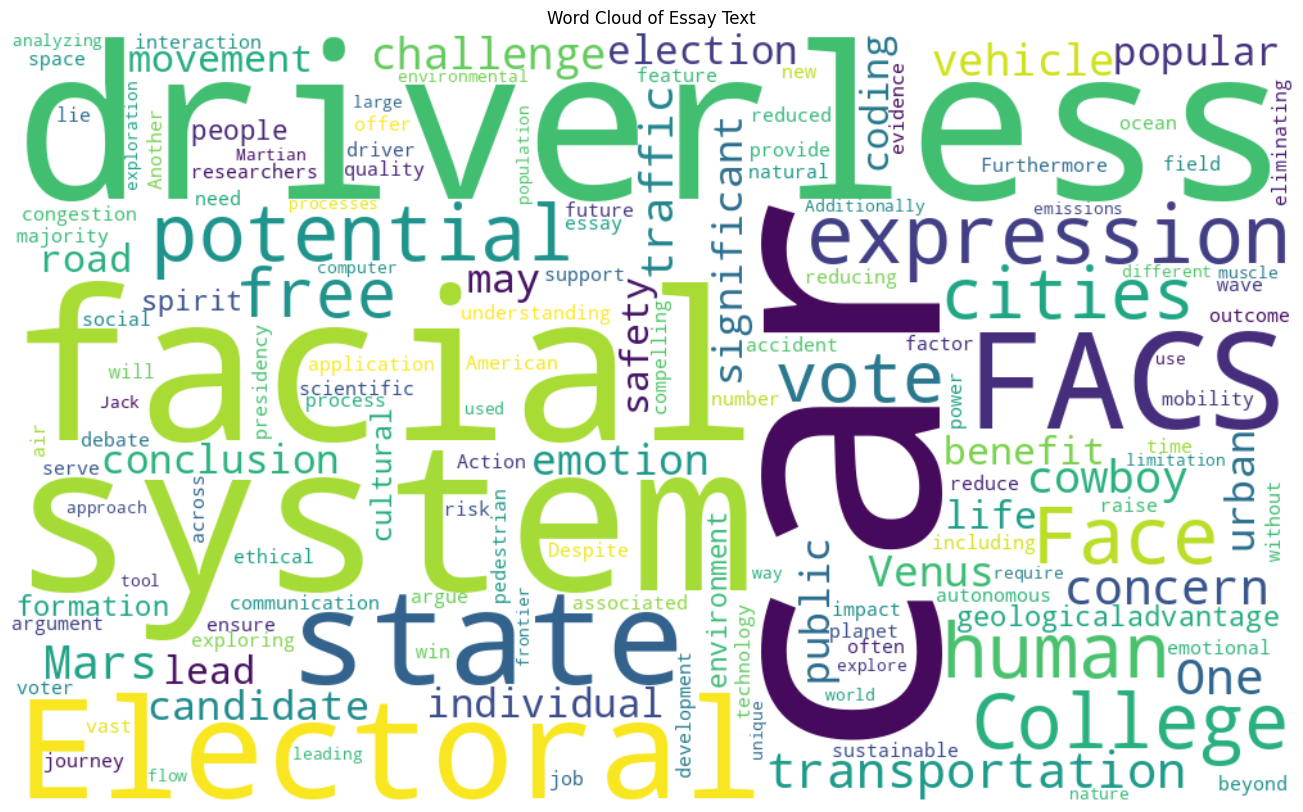

In [ ]:
all_text = ' '.join(train['text'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(["the", "a", "an", "is", "it", "this", "that", "and", "of", "to", "in", "for", "on", "with", "as", "by"])

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    stopwords=stopwords,
    min_font_size=10,
    max_words=150,
    collocations=False
).generate(all_text)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Essay Text")
plt.show()

Although the generated image is not available, based on the sampled essay content (Driverless Cars, FACS, Mars), the most frequent words would likely include highly thematic terms such as:

- Technology/Science: driverless, cars, autonomous, facial, expressions, LLM, judges.
- Abstract Concepts: potential, system, advantages, disadvantages, ethical, safety.
- General High-Frequency Terms: people, world, community.

This visualization is essential for developing models, as it highlights the key concepts and keywords that LLMs trained on this data would be sensitive to.

# Text Cleaning

The preparation of textual data for a neural network involves multiple sequential steps, transforming raw paragraphs into structured, numerical sequences for the $\textbf{Causal Language Modeling (CLM)}$ task.

The initial phase standardizes the text corpus and segments it into the fundamental training units (sentences).

**Text Cleaning**

The clean_text_from_provided_pipeline function applies extensive normalization to reduce noise and enforce uniformity:

- Lowercasing and Punctuation Removal: Text is converted to lowercase, and standard punctuation is removed.
- ASCII Conversion: UTF-8 encoding and ASCII decoding are used to eliminate non-ASCII characters, ensuring text compatibility.
- Noise Filtering: Specific patterns, including URLs, HTML tags, markers, newlines, and any words containing digits, are removed or replaced.
- Whitespace Standardization: Multiple spaces are consolidated into a single space, and leading/trailing whitespace is stripped.

In [13]:
# --- Dataset Cleaning & Sentence Tokenization ---

def clean_text_from_provided_pipeline(txt):
    txt = str(txt) # Ensure text is string
    # Remove punctuation and convert to lowercase
    txt = "".join(v for v in txt if v not in string.punctuation).lower()
    # Encode to utf8 and decode to ascii, ignoring errors (removes non-ascii chars)
    txt = txt.encode("utf8").decode("ascii",'ignore')
    # Additional cleaning
    txt = re.sub(r'##+', ' ', txt) # Remove '##' markers
    txt = re.sub(r'\[.*?\]', '', txt) # Remove text within square brackets
    txt = re.sub(r'https?://\S+|www.\S+', '', txt) # Remove URLs
    txt = re.sub(r'<.*?>+', '', txt) # Remove HTML tags
    txt = re.sub(r'\n', ' ', txt) # Replace newlines with spaces
    txt = re.sub(r'\w*\d\w*', '', txt) # Remove words containing digits
    txt = re.sub(r'\s+', ' ', txt).strip() # Replace multiple spaces with single and strip
    return txt

def tokenize_paragraph_to_sentences_and_clean(paragraph_text):
    """
    Tokenizes a paragraph into sentences and cleans each sentence.
    Returns a list of cleaned sentences.
    """
    sentences = sent_tokenize(paragraph_text)
    # Filter out empty strings after cleaning
    cleaned_sentences = [clean_text_from_provided_pipeline(s) for s in sentences if clean_text_from_provided_pipeline(s)]
    return cleaned_sentences

print("Cleaning and sentence tokenizing training text data...")
# Apply sentence tokenization and cleaning to each paragraph, then flatten the list
all_cleaned_sentences_train = []
for paragraph in train['text']:
    all_cleaned_sentences_train.extend(tokenize_paragraph_to_sentences_and_clean(paragraph))

Cleaning and sentence tokenizing training text data...


In [14]:
print("Cleaning and sentence tokenizing test text data...")
all_cleaned_sentences_test = []
for paragraph in test['text']:
    all_cleaned_sentences_test.extend(tokenize_paragraph_to_sentences_and_clean(paragraph))

Cleaning and sentence tokenizing test text data...


In [15]:
print(f"\nTotal cleaned sentences in training set: {len(all_cleaned_sentences_train)}")
print(f"Total cleaned sentences in test set: {len(all_cleaned_sentences_test)}")
print("\nSample cleaned sentences from training data (first 3):\n")
for i, sentence_sample in enumerate(all_cleaned_sentences_train[:3]):
    print(f"--- Cleaned Train Sentence {i+1} ---")
    print(sentence_sample[:200], "...")
    print("-" * 50)


Total cleaned sentences in training set: 1333
Total cleaned sentences in test set: 361

Sample cleaned sentences from training data (first 3):

--- Cleaned Train Sentence 1 ---
in the realm of extraordinary feats the tale of a cowboy who rode the waves stands out as a testament to the boundless nature of human spirit ...
--------------------------------------------------
--- Cleaned Train Sentence 2 ---
this audacious adventurer with his unwavering determination and unconventional approach defied the societal norms and carved a new path etching his name in the annals of history ...
--------------------------------------------------
--- Cleaned Train Sentence 3 ---
the cowboy raised in the vast open ranges was accustomed to the rhythm of the land the rumble of hooves beneath him and the boundless freedom of the prairie ...
--------------------------------------------------


# Features Engineering

## Tokenization and Vocabulary Building

**Sentence Tokenization**

The tokenize_paragraph_to_sentences_and_clean function utilizes sentence segmentation (using NLTK's sent_tokenize) to break paragraphs into individual sentences. The cleaning function is applied to each resulting sentence, yielding a list of cleaned, discrete textual units.

**Tokenization and Vocabulary Building**

This stage converts the cleaned words into numerical tokens (integer IDs) and prepares the sequence structure. The Keras Tokenizer object is used for mapping words to indices.

- Sequence Markers: Every cleaned sentence is augmented with control tokens: `<SOS>` (Start-of-Sequence) is prepended, and `<EOS>` (End-of-Sequence) is appended. These markers are essential for teaching the autoregressive model where generation begins and terminates.
- Lexical Truncation: The tokenizer is initialized with a maximum vocabulary size (`VOCAB_SIZE=5500`). This implements lexical truncation, ensuring that only the most frequent words are mapped, which keeps the size of the $\textbf{Embedding Layer}$ manageable.
- Out-of-Vocabulary (`OOV`) Handling: The `<OOV>` token is explicitly assigned an ID (typically 1). This mechanism addresses the $\textbf{Closed-Vocabulary Problem}$: any word encountered in the test or generation phase that was not among the top 5500 training words is mapped to the `<OOV>` index, allowing the model to assign a generalized representation to unknown words.

**Causal Language Modeling ($\text{CLM}$) Sequence Generation**

The `get_sequence_of_tokens` function generates the paired input-output training samples necessary for next-token prediction.

- Autoregressive Objective: The fundamental principle is $\textbf{Causal Language Modeling}$. The model is trained to predict the token $\text{w}_{n}$ given the preceding sequence $\text{[w}_{1}\text{, w}_{2}\text{, ..., w}_{n-1}\text{]}$.
- N-gram Generation: The process iterates through the tokenized list for each sentence, generating all possible prefix subsequences ($\text{N-grams}$). For a sequence of length $L$, $L-1$ unique training samples are created.
- Token ID Clipping: A check is performed on the generated token IDs. Any ID that exceeds the defined `VOCAB_SIZE_FINAL`is replaced with the `<OOV>` ID. This ensures the indices passed to the Embedding Layer are valid, preventing array indexing errors.

**Sequence Standardization and Target Label Splitting**

**Padding Sequences and Predictor-Label Split**

Deep learning models, including Transformers, require fixed-size input tensors.

- Padding: The `pad_sequences` utility is used to standardize the length of all $\text{N-gram}$ sequences. All sequences are padded with zero values at the beginning (`padding='pre'`) to match the length of the longest sequence in the corpus (`max_sequence_len`). The padding value (0) is a non-meaningful placeholder.
- Input-Target Separation: Each padded sequence is split into two components:
- Predictors ($\text{X}$): All tokens except the final one ($\text{w}_{1}$ to $\text{w}_{n-1}$). This serves as the fixed-length input to the model.
- Label ($\text{y}$): The final token ($\text{w}_{n}$). This is the ground truth target token the model must predict.

**Attention Mask Generation**

A binary $\textbf{Attention Mask}$ is created alongside the predictors. This mask assigns $\text{1}$ to every non-zero (actual word) token and $\text{0}$ to every padding token. The mask is provided to the Transformer's $\textbf{Self-Attention}$ mechanism, instructing it to disregard the padding tokens when calculating attention scores, thereby preventing them from degrading the learned representation.

**Tokenization and Vocabulary Building Example**

In [ ]:
example_train_data = {
    'cleaned_text': [
        "this is a great movie",
        "the movie was fantastic",
        "i love this film",
        "what a terrible movie",
        "this film is bad"
    ]
}
example_test_data = {
    'cleaned_text': [
        "a fantastic film it was",
        "i hate this bad movie",
        "great acting"
    ]
}

example_train = pd.DataFrame(example_train_data)
example_test = pd.DataFrame(example_test_data)

print("--- Original Training Texts ---")
for example_text in example_train['cleaned_text']:
    print(f"- {example_text}")
print("\n--- Original Test Texts ---")
for example_text in example_test['cleaned_text']:
    print(f"- {example_text}")

example_VOCAB_SIZE = 10
example_OOV_TOKEN = "<OOV>"
example_SOS_TOKEN = "<SOS>"
example_EOS_TOKEN = "<EOS>"

example_texts_for_tokenization_train = [f"{example_SOS_TOKEN} {example_text} {example_EOS_TOKEN}" for example_text in example_train['cleaned_text']]
example_texts_for_tokenization_test = [f"{example_SOS_TOKEN} {example_text} {example_EOS_TOKEN}" for example_text in example_test['cleaned_text']]

print(f"\n--- Training Texts with Special Tokens ---")
for example_text in example_texts_for_tokenization_train:
    print(f"- {example_text}")

print(f"\n--- Initializing Tokenizer with num_words={example_VOCAB_SIZE} and oov_token='{example_OOV_TOKEN}' ---")
example_tokenizer = Tokenizer(num_words=example_VOCAB_SIZE, oov_token=example_OOV_TOKEN, filters='')

example_tokenizer.fit_on_texts(example_texts_for_tokenization_train)

print(f"\n--- Word Counts (before explicit special token addition) ---")
example_sorted_word_counts = sorted(example_tokenizer.word_counts.items(), key=lambda x: x[1], reverse=True)
for example_word, example_count in example_sorted_word_counts:
    print(f"'{example_word}': {example_count}")

print(f"\n--- Initial Word Index (top {example_VOCAB_SIZE} words + OOV if present) ---")
print(example_tokenizer.word_index)


print(f"\n--- Explicitly adding special tokens if not present ---")
for example_token in [example_SOS_TOKEN, example_EOS_TOKEN, example_OOV_TOKEN]:
    if example_token not in example_tokenizer.word_index:
        example_tokenizer.word_index[example_token] = len(example_tokenizer.word_index) + 1
        print(f"Added '{example_token}' with ID {example_tokenizer.word_index[example_token]}")
    else:
        print(f"'{example_token}' already has ID {example_tokenizer.word_index[example_token]}")


example_VOCAB_SIZE_FINAL = min(len(example_tokenizer.word_index) + 1, example_VOCAB_SIZE + 1)

print(f"\n--- Final Tokenizer Vocabulary Information ---")
print(f"Tokenizer vocabulary size: {example_VOCAB_SIZE_FINAL}")
print(f"Mapping of example_SOS_TOKEN: {example_tokenizer.word_index.get(example_SOS_TOKEN)}")
print(f"Mapping of example_EOS_TOKEN: {example_tokenizer.word_index.get(example_EOS_TOKEN)}")
print(f"Mapping of example_OOV_TOKEN: {example_tokenizer.word_index.get(example_OOV_TOKEN)}")

print(f"\n--- Full Final Word Index ---")
print(example_tokenizer.word_index)

example_train_sequences = example_tokenizer.texts_to_sequences(example_texts_for_tokenization_train)
print(f"\n--- Sample Training Sequences (first 2) ---")
for example_i, example_seq in enumerate(example_train_sequences[:2]):
    example_original_text = example_texts_for_tokenization_train[example_i]
    print(f"Original: {example_original_text}")
    print(f"Sequence: {example_seq}")
    example_decoded_words = [list(example_tokenizer.word_index.keys())[list(example_tokenizer.word_index.values()).index(example_idx)] if example_idx != 0 else 'PAD' for example_idx in example_seq]
    print(f"Decoded:  {' '.join(example_decoded_words)}\n")

example_test_sequences = example_tokenizer.texts_to_sequences(example_texts_for_tokenization_test)
print(f"\n--- Sample Test Sequences (first 2) ---")
for example_i, example_seq in enumerate(example_test_sequences[:2]):
    example_original_text = example_texts_for_tokenization_test[example_i]
    print(f"Original: {example_original_text}")
    print(f"Sequence: {example_seq}")
    example_decoded_words = [list(example_tokenizer.word_index.keys())[list(example_tokenizer.word_index.values()).index(example_idx)] if example_idx != 0 else 'PAD' for example_idx in example_seq]
    print(f"Decoded:  {' '.join(example_decoded_words)}\n")

example_new_sentence = f"{example_SOS_TOKEN} this is a really amazing new film {example_EOS_TOKEN}"
example_new_sequence = example_tokenizer.texts_to_sequences([example_new_sentence])
print(f"\n--- Example with OOV words ---")
print(f"Original new sentence: {example_new_sentence}")
print(f"Sequence for new sentence: {example_new_sequence}")
example_decoded_words_new = [list(example_tokenizer.word_index.keys())[list(example_tokenizer.word_index.values()).index(example_idx)] if example_idx != 0 else 'PAD' for example_idx in example_new_sequence[0]]
print(f"Decoded new sentence:  {' '.join(example_decoded_words_new)}")

--- Original Training Texts ---
- this is a great movie
- the movie was fantastic
- i love this film
- what a terrible movie
- this film is bad

--- Original Test Texts ---
- a fantastic film it was
- i hate this bad movie
- great acting

--- Training Texts with Special Tokens ---
- <SOS> this is a great movie <EOS>
- <SOS> the movie was fantastic <EOS>
- <SOS> i love this film <EOS>
- <SOS> what a terrible movie <EOS>
- <SOS> this film is bad <EOS>

--- Initializing Tokenizer with num_words=10 and oov_token='<OOV>' ---

--- Word Counts (before explicit special token addition) ---
'<sos>': 5
'<eos>': 5
'this': 3
'movie': 3
'is': 2
'a': 2
'film': 2
'great': 1
'the': 1
'was': 1
'fantastic': 1
'i': 1
'love': 1
'what': 1
'terrible': 1
'bad': 1

--- Initial Word Index (top 10 words + OOV if present) ---
{'<OOV>': 1, '<sos>': 2, '<eos>': 3, 'this': 4, 'movie': 5, 'is': 6, 'a': 7, 'film': 8, 'great': 9, 'the': 10, 'was': 11, 'fantastic': 12, 'i': 13, 'love': 14, 'what': 15, 'terrible': 16, 'b

## Tokenization

In [ ]:
VOCAB_SIZE = 5500
OOV_TOKEN = "<OOV>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"

texts_for_tokenization_train = [f"{SOS_TOKEN} {text} {EOS_TOKEN}" for text in all_cleaned_sentences_train]
texts_for_tokenization_test = [f"{SOS_TOKEN} {text} {EOS_TOKEN}" for text in all_cleaned_sentences_test]

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN, filters='')
tokenizer.fit_on_texts(texts_for_tokenization_train)

for token in [SOS_TOKEN, EOS_TOKEN]:
    if token not in tokenizer.word_index:
        tokenizer.word_index[token] = len(tokenizer.word_index) + 1

VOCAB_SIZE_FINAL = min(len(tokenizer.word_index) + 1, VOCAB_SIZE + 1)

print(f"\nTokenizer vocabulary size (for embedding layer, includes padding): {VOCAB_SIZE_FINAL}")
print(f"Mapping of SOS_TOKEN: {tokenizer.word_index.get(SOS_TOKEN)}")
print(f"Mapping of EOS_TOKEN: {tokenizer.word_index.get(EOS_TOKEN)}")
print(f"Mapping of OOV_TOKEN: {tokenizer.word_index.get(OOV_TOKEN)}")


Tokenizer vocabulary size (for embedding layer, includes padding): 3425
Mapping of SOS_TOKEN: 3423
Mapping of EOS_TOKEN: 3424
Mapping of OOV_TOKEN: 1


## N-Gram Tokens Sequence Generation

In [ ]:
def get_sequence_of_tokens(corpus_sentences, tokenizer_obj):
    input_sequences = []
    oov_id = tokenizer_obj.word_index.get(OOV_TOKEN, 1)

    max_valid_id = VOCAB_SIZE_FINAL - 1

    for line in corpus_sentences:
        token_list = tokenizer_obj.texts_to_sequences([line])[0]

        clipped_token_list = [
            token_id if token_id < max_valid_id else oov_id
            for token_id in token_list
        ]

        for i in range(1, len(clipped_token_list)):
            n_gram_sequence = clipped_token_list[:i+1]
            input_sequences.append(n_gram_sequence)
    return input_sequences

inp_sequences_train = get_sequence_of_tokens(texts_for_tokenization_train, tokenizer)
inp_sequences_test = get_sequence_of_tokens(texts_for_tokenization_test, tokenizer)

print(f"\nTotal N-gram sequences for training: {len(inp_sequences_train)}")
print(f"Total N-gram sequences for testing: {len(inp_sequences_test)}")
print("\nSample N-gram sequences from training data (first 5):\n")
for i, seq in enumerate(inp_sequences_train[:5]):
    print(seq)


Total N-gram sequences for training: 31324
Total N-gram sequences for testing: 7963

Sample N-gram sequences from training data (first 5):

[3, 9]
[3, 9, 2]
[3, 9, 2, 254]
[3, 9, 2, 254, 5]
[3, 9, 2, 254, 5, 226]


## Sequences Padding

In [ ]:
def generate_padded_sequences(input_sequences):
    if not input_sequences:
        print("Warning: input_sequences is empty. Cannot determine max_sequence_len.")
        return np.array([]), np.array([]), 0

    max_sequence_len = max([len(x) for x in input_sequences])
    input_sequences_padded = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre', value=0))

    predictors = input_sequences_padded[:, :-1]
    label = input_sequences_padded[:, -1]

    return predictors, label, max_sequence_len

predictors_train, label_train, max_sequence_len_train = generate_padded_sequences(inp_sequences_train)

if inp_sequences_test:
    predictors_test_padded = pad_sequences(
        [seq[:-1] for seq in inp_sequences_test],
        maxlen=max_sequence_len_train - 1,
        padding='pre',
        value=0
    )
    label_test = np.array([seq[-1] for seq in inp_sequences_test])
else:
    predictors_test_padded = np.array([])
    label_test = np.array([])

print(f"\nShape of predictors_train: {predictors_train.shape}")
print(f"Shape of label_train: {label_train.shape}")
print(f"Max sequence length for padding (from training data): {max_sequence_len_train}")
print(f"Actual model input length (max_sequence_len - 1): {max_sequence_len_train - 1}")
print(f"Shape of predictors_test (padded to training maxlen): {predictors_test_padded.shape}")
print(f"Shape of label_test: {label_test.shape}")


Shape of predictors_train: (31324, 55)
Shape of label_train: (31324,)
Max sequence length for padding (from training data): 56
Actual model input length (max_sequence_len - 1): 55
Shape of predictors_test (padded to training maxlen): (7963, 55)
Shape of label_test: (7963,)


## Train and  Validation Split

**Train-Validation Split**

To ensure the trained model generalizes to unseen data, the full training dataset is partitioned using `train_test_split`:

- Validation Set Purpose: A $20\%$ portion (`VAL_SPLIT_RATIO=0.2`) is reserved as a $\textbf{Validation Set}$. This set acts as an unbiased measure of model performance during training.
- Overfitting Prevention: Monitoring performance on the validation set is essential for detecting $\textbf{Overfitting}$, a phenomenon where a model performs well on the training data but fails to generalize to new examples.
- Reproducibility: A fixed `random_state=42` is employed to guarantee the exact same data split across multiple experimental runs, which is crucial for reliable model comparison.

The final output is six sets of paired data `X_train`, `y_train`, `mask_train`, `X_val`, `y_val`, `mask_val`, ready for ingestion by the neural network.

In [ ]:
VAL_SPLIT_RATIO = 0.2
attention_mask_train_full = (predictors_train != 0).astype(int)

X_train, X_val, y_train, y_val, mask_train, mask_val = train_test_split(
    predictors_train, label_train, attention_mask_train_full, 
    test_size=VAL_SPLIT_RATIO, random_state=42
)

print(f"\n--- Data Split Summary ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"mask_train shape: {mask_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"mask_val shape: {mask_val.shape}")


--- Data Split Summary ---
X_train shape: (25059, 55)
y_train shape: (25059,)
mask_train shape: (25059, 55)
X_val shape: (6265, 55)
y_val shape: (6265,)
mask_val shape: (6265, 55)


# Model Training

## Model Architecture, Model Building, and Model Training (Keras)

**The Transformer Architecture**
Before diving into the code, let’s understand the key components of a Transformer:

**Self-Attention Mechanism**
* At the heart of the Transformer is the self-attention mechanism, which allows the model to weigh the importance of different words in a sequence when processing each word. For each position in the input sequence, self-attention computes a weighted sum of all positions, where the weights are determined by how relevant each position is to the current one. The self-attention mechanism is implemented using three projections of the input: queries (Q), keys (K), and values (V).

**Multi-Head Attention**
* Instead of performing a single attention function, the Transformer uses multiple attention heads, allowing it to focus on different parts of the input simultaneously. Each head performs attention on projected versions of Q, K, and V, and the results are concatenated and linearly transformed.

**Position-wise Feed-Forward Networks**
* After the attention layer, each position in the sequence is processed by a feed-forward neural network, applied identically to each position. This consists of two linear transformations with a ReLU activation in between.

**Positional Encoding**
* Since the Transformer doesn’t use recurrence or convolution, it needs a way to incorporate positional information. This is done through positional encodings, which are added to the input embeddings to provide information about the position of each token in the sequence.

## Model Architecture

**Model Capacity and Architecture**

- Increased Model Dimensions: `EMBEDDING_DIM` is set to 256, allowing for richer token representations. `FF_DIM` is set to 512, providing ample capacity for the feed-forward networks within each Transformer block.

- Deeper Sequence Modeling: `NUM_TRANSFORMER_BLOCKS` is set to 2, enabling the model to learn more hierarchical and complex patterns.

- Multi-Head Attention: Configured with `NUM_HEADS` set to 4, allowing the model to attend to different parts of the input sequence simultaneously.

- Context Understanding: The self-attention mechanism inherently captures relationships between all tokens. For text generation, `use_causal_mask=True` is applied in `MultiHeadAttention` to ensure predictions are based only on preceding tokens. A dynamic 3D `attention_mask` is generated for padding, preventing attention to invalid tokens.

- Positional Embeddings: Positional encodings are added to token embeddings to inject sequence order information into the model.

**Regularization and Normalization**
- Dropout Regularization: `DROPOUT_RATE` is set to 0.2, applied after embeddings, multi-head attention, and feed-forward networks to prevent overfitting.

- L2 Regularization: A small `L2_REG` is applied to embedding, dense, and attention kernel weights to further regularize the model and prevent overly large weights.

- Layer Normalization: Applied after both the multi-head attention and feed-forward network within each Transformer block to stabilize training and improve gradient flow.

**Training Optimization**
- Optimizer: The model utilizes the AdamW optimizer with a `learning_rate` of 0.001, `weight_decay` of 0.01, and `clipnorm` (gradient clipping) of 1.0. This helps in more stable training and improved generalization.

- Learning Rate Scheduler: A `ReduceLROnPlateau` callback is used to dynamically reduce the learning rate by a factor of 0.5 when `val_loss` plateaus for `patience=3` epochs, with a `min_lr` of $1 \times 10^{-6}$. This aids in better convergence.

- Early Stopping: An `EarlyStopping` callback monitors `val_loss` with a patience of 5 epochs. It restore_best_weights to the model if training stops early, ensuring the best performing model is retained.

- Epochs: `EPOCHS` is set to 1, serving as a starting point for training iterations. This can be increased based on training progress.

- Batch Size: `BATCH_SIZE` is set to 16 for training, offering a balance between memory usage and stable gradient updates.

- Loss Function: `SparseCategoricalCrossentropy(from_logits=False)` is used as the loss function, appropriate for next-token prediction with integer-encoded labels and softmax output.

**Impact on Accuracy and Stability**

  These configurations are designed to significantly enhance the model's performance:

**Accuracy Improvement:**

- Increased Capacity: The higher `EMBEDDING_DIM, FF_DIM, and NUM_TRANSFORMER_BLOCKS` allow the Transformer to learn more complex linguistic patterns and richer token representations, addressing potential underfitting.

- Self-Attention and Causal Masking: The core Transformer architecture, with its multi-head self-attention and causal masking, enables effective context capture and accurate next-token prediction, which is crucial for text generation tasks.

- Regularization: `DROPOUT_RATE and L2_REG` are crucial for preventing overfitting, leading to better generalization and potentially higher validation accuracy. Layer Normalization also contributes to better generalization by stabilizing training.

- AdamW Optimizer with Gradient Clipping: The `AdamW` optimizer, coupled with gradient clipping (`clipnorm=1.0`), provides robust optimization, preventing issues like exploding gradients and leading to improved convergence and higher training and validation accuracy.

**Training Stability:**

- Layer Normalization: Stabilizes training by normalizing activations within each block, promoting smoother gradient flow.

- AdamW and Gradient Clipping: These optimizer features inherently improve training stability by managing gradient magnitudes.

- Learning Rate Scheduling and Early Stopping: Dynamically adjusting the learning rate helps the model navigate loss landscapes more effectively, escaping plateaus. Increased patience in EarlyStopping allows the model more time to learn and potentially reach a better local minimum, while preventing excessive training if performance plateaus.

**OOM Resolution:** Reducing the `BATCH_SIZE` to 16, and configuring `EMBEDDING_DIM` and `NUM_TRANSFORMER_BLOCKS` (which were selected as 256 and 2, respectively, in the code), combined with potential mixed precision training (not explicitly shown in code but a common strategy), helps to lower GPU memory demands and prevent out-of-memory errors. The optimized AdamW optimizer and gradient clipping further contribute to stable and efficient resource utilization during training.

In [ ]:
class AttentionMaskLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionMaskLayer, self).__init__(**kwargs)

    def call(self, padding_mask):
        query_mask = tf.cast(tf.expand_dims(padding_mask, axis=2), dtype=tf.float32)
        key_mask = tf.cast(tf.expand_dims(padding_mask, axis=1), dtype=tf.float32)
        attention_mask = query_mask * key_mask
        return attention_mask

def build_transformer_decoder_model(
    vocab_size, maxlen, embedding_dim, num_heads, ff_dim, num_transformer_blocks, dropout_rate=0.2, l2_reg=1e-5
):
    inputs = Input(shape=(maxlen,), dtype=tf.int32)
    attention_mask_input = Input(shape=(maxlen,), dtype=tf.int32, name='attention_mask_input')

    attention_mask_3d = AttentionMaskLayer()(attention_mask_input)

    token_embeddings = Embedding(vocab_size, embedding_dim, embeddings_regularizer=l2(l2_reg))(inputs)
    position_embeddings = Embedding(maxlen, embedding_dim)(tf.range(start=0, limit=maxlen, delta=1))
    x = token_embeddings + position_embeddings
    x = Dropout(dropout_rate)(x)

    for _ in range(num_transformer_blocks):
        attn_output = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embedding_dim // num_heads,
            dropout=dropout_rate,
            kernel_regularizer=l2(l2_reg)
        )(query=x, value=x, key=x, attention_mask=attention_mask_3d, use_causal_mask=True)
        attn_output = Dropout(dropout_rate)(attn_output)
        attn_output = LayerNormalization(epsilon=1e-6)(x + attn_output)

        ffn_output = Dense(ff_dim, activation="relu", kernel_regularizer=l2(l2_reg))(attn_output)
        ffn_output = Dense(embedding_dim, kernel_regularizer=l2(l2_reg))(ffn_output)
        ffn_output = Dropout(dropout_rate)(ffn_output)
        x = LayerNormalization(epsilon=1e-6)(attn_output + ffn_output)

    outputs = Dense(vocab_size, activation="softmax", dtype='float32', kernel_regularizer=l2(l2_reg))(x)
    outputs = outputs[:, -1, :]

    model = Model(inputs=[inputs, attention_mask_input], outputs=outputs)
    return model

EMBEDDING_DIM = 256
NUM_HEADS = 4
FF_DIM = 512
NUM_TRANSFORMER_BLOCKS = 2
DROPOUT_RATE = 0.2
L2_REG = 1e-5
BATCH_SIZE = 16
EPOCHS = 100

MODEL_INPUT_LENGTH_FOR_TRANSFORMER = max(1, max_sequence_len_train - 1)

transformer_model = build_transformer_decoder_model(
    vocab_size=VOCAB_SIZE_FINAL,
    maxlen=MODEL_INPUT_LENGTH_FOR_TRANSFORMER,
    embedding_dim=EMBEDDING_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_transformer_blocks=NUM_TRANSFORMER_BLOCKS,
    dropout_rate=DROPOUT_RATE,
    l2_reg=L2_REG
)

transformer_model.compile(
    optimizer=AdamW(learning_rate=0.001, weight_decay=0.01, clipnorm=1.0),
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("\n--- Transformer Model Summary ---")
transformer_model.summary()

def calculate_perplexity(model, x_data_list, y_data, batch_size=16):
    """
    Calculates perplexity on the given dataset using the trained model.
    Adapted for models with multiple inputs (e.g., [input_ids, attention_mask]).

    Args:
        model (tf.keras.Model): The trained Transformer model.
        x_data_list (list or tuple): A list/tuple of input arrays (e.g., [X_val, mask_val]).
        y_data (np.ndarray): Target token sequences.
        batch_size (int): Batch size for prediction.

    Returns:
        float: Perplexity score.
    """
    print("\n--- Calculating Perplexity ---")
    if len(x_data_list[0]) == 0:
        print("Warning: Input data for perplexity is empty. Returning inf.")
        return float('inf')
    
    loss = model.evaluate(x_data_list, y_data, batch_size=batch_size, verbose=0)[0]
    
    perplexity = np.exp(loss)
    
    print(f"Perplexity: {perplexity:.2f}")
    return perplexity


early_stopping_callback = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

print(f"\n--- Training Transformer Model ---")
if len(X_train) > 0 and len(y_train) > 0:
    history = transformer_model.fit(
        x=[X_train, mask_train],
        y=y_train,
        validation_data=([X_val, mask_val], y_val),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=[early_stopping_callback, lr_scheduler]
    )

    print("\nTraining complete!")

    print("\n--- Calculating Perplexity on Training Dataset (after training) ---")
    if len(X_train) > 0 and len(y_train) > 0:
        train_perplexity = calculate_perplexity(transformer_model, [X_train, mask_train], y_train, batch_size=BATCH_SIZE)
        print(f"Training Perplexity: {train_perplexity:.2f}")
    else:
        print("Skipping training perplexity calculation: X_train or y_train not available or empty.")

else:
    print("Skipping training due to empty training data.")

I0000 00:00:1761737246.713551      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1761737246.714341      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



--- Transformer Model Summary ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 55)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 55, 256)   │    876,800 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask_inp… │ (None, 55)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 55, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask_lay… │ (None, 55, 55)    │          0 │ attention_mask_i… │
│ (AttentionMaskLaye… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 55, 256)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 55, 55)    │          0 │ attention_mask_l… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 55, 256)   │    263,168 │ cast[0][0],       │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0],    │
│                     │                   │            │ dropout[0][0],    │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 55, 256)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 55, 256)   │          0 │ dropout[0][0],    │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 55, 256)   │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 55, 512)   │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 55, 256)   │    131,328 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 55, 256)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 55, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 55, 256)   │        512 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 55, 55)    │          0 │ attention_mask_l… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 55, 256)   │    263,168 │ cast_1[0][0],     │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
│                     │                   │            │ layer_normalizat… │
│                     │                   │            │ layer_normalizat

 Total params: 2,811,233 (10.72 MB)

...


--- Training Transformer Model ---
Epoch 1/100


I0000 00:00:1761737260.327232     116 service.cc:148] XLA service 0x7cf63001fe20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761737260.328200     116 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1761737260.328221     116 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1761737261.866899     116 cuda_dnn.cc:529] Loaded cuDNN version 90300


  12/1567 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.0334 - loss: 7.9023     

I0000 00:00:1761737270.407810     116 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1567/1567 ━━━━━━━━━━━━━━━━━━━━ 45s 15ms/step - accuracy: 0.0773 - loss: 6.5697 - val_accuracy: 0.1457 - val_loss: 5.8256 - learning_rate: 0.0010
Epoch 2/100
1567/1567 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.1619 - loss: 5.4662 - val_accuracy: 0.2002 - val_loss: 5.4603 - learning_rate: 0.0010
Epoch 3/100
1567/1567 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.2174 - loss: 4.8873 - val_accuracy: 0.2236 - val_loss: 5.2036 - learning_rate: 0.0010
Epoch 4/100
1567/1567 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.2604 - loss: 4.3734 - val_accuracy: 0.2460 - val_loss: 5.0998 - learning_rate: 0.0010
Epoch 5/100
1567/1567 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.2987 - loss: 3.9731 - val_accuracy: 0.2524 - val_loss: 5.0639 - learning_rate: 0.0010
Epoch 6/100
1567/1567 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.3387 - loss: 3.5815 - val_accuracy: 0.2750 - val_loss: 4.9950 - learning_rate: 0.0010
Epoch 7/100
1567/1567 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.3708 

- **[Attention Is All You Need](https://arxiv.org/abs/1706.03762)**
- **[Building a Text Generation Transformer from Scratch: A Deep Dive](https://medium.com/@aadit.kshirsagar/building-a-text-generation-transformer-from-scratch-a-deep-dive-3dcde380013b)**

## Model Validation (Perplexity)

Perplexity (PPL) is the standard intrinsic metric used to evaluate the quality of a language model. In simple terms, it measures how well a probability model predicts a sample. For a Causal Language Model (CLM), which is trained to predict the next token in a sequence, PPL quantifies the uncertainty the model has when predicting tokens on unseen data (like a validation or test set).

Key Concept: Relationship with Cross-Entropy Loss

Perplexity is mathematically defined as the exponentiation of the average cross-entropy loss ($\text{Loss}$) calculated over a test sequence of tokens, $W = (w_1, w_2, \dots, w_N)$:

$$\text{PPL}(W) = e^{\text{Loss}}$$

Where $\text{Loss}$ is the average negative log-likelihood of the test sequence, which is exactly what a modern neural network minimizes during training using the SparseCategoricalCrossentropy loss function.$$\text{Loss} = \frac{1}{N} \sum_{i=1}^{N} -\log(P(w_i | w_{1}, \dots, w_{i-1}))$$

**Interpretation**

Perplexity can be conceptually understood as the weighted average number of choices the model has when predicting the next token.
- Low Perplexity (Good): A low PPL (approaching 1) means the model is very confident and highly accurate in predicting the next tokens, often assigning a very high probability to the correct word. The model is a good fit for the data.
- High Perplexity (Bad): A high PPL indicates the model is unsure of its predictions, spreading its probability mass across many different tokens, or consistently failing to predict the correct next token. The model either overfit the training data or is generally poor at modeling the test set.

In [ ]:
def calculate_perplexity(model, x_data_list, y_data, batch_size=16):
    """
    Calculates perplexity on the given dataset using the trained model.
    Adapted for models with multiple inputs (e.g., [input_ids, attention_mask]).

    Args:
        model (tf.keras.Model): The trained Transformer model.
        x_data_list (list or tuple): A list/tuple of input arrays (e.g., [X_val, mask_val]).
        y_data (np.ndarray): Target token sequences.
        batch_size (int): Batch size for prediction.

    Returns:
        float: Perplexity score.
    """
    print("\n--- Calculating Perplexity ---")
    if len(x_data_list[0]) == 0:
        print("Warning: Input data for perplexity is empty. Returning inf.")
        return float('inf')
    
    loss = model.evaluate(x_data_list, y_data, batch_size=batch_size, verbose=0)[0]
    
    perplexity = np.exp(loss)
    
    print(f"Perplexity: {perplexity:.2f}")
    return perplexity

print("\n--- Calculating Perplexity on Validation Dataset ---")
if 'X_val' in locals() and 'y_val' in locals() and len(X_val) > 0:
    val_perplexity = calculate_perplexity(transformer_model, [X_val, mask_val], y_val, batch_size=BATCH_SIZE)
    print(f"\nValidation Perplexity: {val_perplexity:.2f}")
else:
    print("Skipping validation perplexity calculation: X_val or y_val not available or empty.")


--- Calculating Perplexity on Validation Dataset ---

--- Calculating Perplexity ---
Perplexity: 147.68

Validation Perplexity: 147.68


**Result Interpretation**

A perplexity score of 147.68 on the validation set means that, on average, the model finds itself having to choose from about 147 distinct words when predicting the next token.

# Model Evaluation

## Perplexity, Rouge-L, Rouge-S, and Rouge-SU

**Perplexity**

The first section of the code implements the standard intrinsic evaluation metric for a language model: Perplexity (PPL). Perplexity quantifies the uncertainty of a probability model (our Transformer Decoder) when it attempts to predict the next token in a sequence of unseen text, such as the validation or test set. It is derived directly from the model's Cross-Entropy Loss ($\text{Loss}$).The mathematical relationship is defined as:

$$\text{PPL} = e^{\text{Loss}}$$

The Cross-Entropy Loss is the average negative log-likelihood that the model assigns to the correct target tokens. Therefore, a low PPL (approaching 1) indicates that the model is highly confident in its predictions and is a strong fit for the underlying distribution of the data. Conversely, a high PPL means the model is unsure of its predictions, assigning relatively low probabilities to the correct tokens.

**Text Generation and ROUGE**

**Text Generation**

The second part of the code transitions from statistical measurement (PPL) to practical application (text generation) and linguistic quality assessment (ROUGE). Autoregressive Generation and Temperature SamplingThe Transformer Decoder is an autoregressive model, meaning it generates text one token at a time, using the previously generated tokens as input for the next prediction.In the $\text{generate\_text}$ function, after the model outputs a probability distribution over the vocabulary for the next token, Temperature Sampling is used to introduce controlled randomness:

- The temperature ($\tau$) hyperparameter (set to $\text{0.7}$) is applied to flatten or sharpen the probability distribution.
- Low $\tau$ (e.g., 0.1): Makes predictions deterministic and predictable by heavily favoring the most likely tokens.
- High $\tau$ (e.g., 1.0): Increases randomness and creativity, potentially leading to less coherent but more diverse output.The chosen $\text{0.7}$ aims for a balance between these two extremes. Critically, special tokens like the Out-of-Vocabulary ($\langle OOV \rangle$) token and the padding token are deliberately masked (given zero probability) to prevent the model from generating them in the final output.

**ROUGE**

ROUGE (Recall-Oriented Understudy for Gisting Evaluation) is a family of metrics used to evaluate the quality of automatically generated text by comparing it against a human-written reference text. It is a recall-based metric, focusing on how many units (words or word sequences) from the reference text are recovered by the generated text.

- ROUGE-L F1 : Measures the longest common subsequence (LCS) of words between the generated and reference texts. Since it is sequence-based, it rewards structural similarity, reflecting how well the generated text maintains the overall flow or grammar of the reference.
- ROUGE-S : Measures the overlap of skip-bigrams. A skip-bigram is any pair of words, regardless of the distance between them (e.g., "the car" in "the big red car"). This metric assesses the model's ability to maintain important long-range word associations.
- ROUGE-SU : Combines the skip-bigram overlap with unigram (single word) overlap, providing a more comprehensive measure of content similarity.

In [ ]:
def prepare_input_prompts(reference_texts, tokenizer_obj, max_prompt_length=10, sos_token="<SOS>"):
    input_sequences = []
    sos_token_id = tokenizer_obj.word_index.get(sos_token)
    oov_token_id = tokenizer_obj.word_index.get(OOV_TOKEN)
    
    if sos_token_id is None:
        print(f"Warning: SOS_TOKEN '{sos_token}' ID not found in tokenizer.word_index. Using OOV_TOKEN_ID for prompts.")
        sos_token_id = oov_token_id
    if oov_token_id is None:
        print(f"Error: OOV_TOKEN '{OOV_TOKEN}' ID not found in tokenizer.word_index. Critical issue!")
        return []

    max_valid_id = VOCAB_SIZE_FINAL - 1

    for text in reference_texts:
        words_list = text.split()[:max_prompt_length]
        token_sequence_from_text = tokenizer_obj.texts_to_sequences([" ".join(words_list)])[0]
        
        clipped_tokens = [sos_token_id] + [
            token_id if token_id < max_valid_id else oov_token_id
            for token_id in token_sequence_from_text
        ]
        input_sequences.append(clipped_tokens)
    return input_sequences


def generate_text(model, tokenizer_obj, input_prompts, max_generation_length, max_sequence_len_model_input, vocab_size_final, temperature=0.7):
    generated_texts = []
    sos_token_id = tokenizer_obj.word_index.get(SOS_TOKEN)
    eos_token_id = tokenizer_obj.word_index.get(EOS_TOKEN)
    oov_token_id = tokenizer_obj.word_index.get(OOV_TOKEN)

    if sos_token_id is None or eos_token_id is None or oov_token_id is None:
        print(f"Error: Special token IDs not found for generation. SOS:{sos_token_id}, EOS:{eos_token_id}, OOV:{oov_token_id}")
        return []

    padding_token_id = 0

    for prompt in input_prompts:
        current_seq = prompt.copy()
        
        current_seq = [token_id if token_id < vocab_size_final else oov_token_id for token_id in current_seq]

        while len(current_seq) < max_generation_length:
            input_seq_padded = pad_sequences([current_seq], maxlen=max_sequence_len_model_input, padding='pre', value=padding_token_id)[0]
            mask = (input_seq_padded != 0).astype(int)

            probs = model.predict([np.array([input_seq_padded]), np.array([mask])], verbose=0)[0]

            if oov_token_id < len(probs):
                probs[oov_token_id] = 0
            if padding_token_id < len(probs):
                probs[padding_token_id] = 0

            sum_probs = np.sum(probs)
            if sum_probs == 0:
                next_token = eos_token_id
            else:
                probs = probs / sum_probs

                probs = np.exp(np.log(probs + 1e-10) / temperature)
                probs = probs / np.sum(probs)

                next_token = np.random.choice(len(probs), p=probs)
            
            if next_token == eos_token_id or next_token == padding_token_id or \
               next_token == oov_token_id or len(current_seq) >= max_generation_length:
                break
            
            current_seq.append(next_token)
        
        text = tokenizer_obj.sequences_to_texts([current_seq])[0]
        text = text.replace(f"{SOS_TOKEN} ", "").replace(f" {EOS_TOKEN}", "").strip()
        text = text.replace(f" {OOV_TOKEN}", "").strip()
        generated_texts.append(text)
    return generated_texts

def calculate_rouge_l_s_su_scores(generated_texts, reference_texts):
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    scores = {'rougeL_f1': [], 'rouge_s': [], 'rouge_su': []}
    
    def get_skip_bigrams(text_words):
        bigrams = set()
        for i in range(len(text_words)):
            for j in range(i + 1, len(text_words)):
                bigrams.add(tuple(sorted((text_words[i], text_words[j]))))
        return bigrams

    for gen, ref in zip(generated_texts, reference_texts):
        gen = gen.strip() if gen and gen.strip() != "empty" else "default"
        ref = ref.strip() if ref and ref.strip() else "default"

        rouge_l = scorer.score(ref, gen)['rougeL'].fmeasure
        scores['rougeL_f1'].append(rouge_l)

        ref_words = ref.split()
        gen_words = gen.split()
        ref_bigrams = get_skip_bigrams(ref_words)
        gen_bigrams = get_skip_bigrams(gen_words)
        
        common_bigrams = ref_bigrams.intersection(gen_bigrams)
        rouge_s = len(common_bigrams) / len(ref_bigrams) if ref_bigrams else 0.0
        scores['rouge_s'].append(rouge_s)

        ref_unigrams = set(ref_words)
        gen_unigrams = set(gen_words)
        
        combined_ref_units = ref_bigrams.union(ref_unigrams)
        combined_gen_units = gen_bigrams.union(gen_unigrams)
        
        common_combined_units = combined_ref_units.intersection(combined_gen_units)
        rouge_su = len(common_combined_units) / len(combined_ref_units) if combined_ref_units else 0.0
        scores['rouge_su'].append(rouge_su)

    return {
        'rougeL_f1': np.mean(scores['rougeL_f1']) if scores['rougeL_f1'] else 0.0,
        'rouge_s': np.mean(scores['rouge_s']) if scores['rouge_s'] else 0.0,
        'rouge_su': np.mean(scores['rouge_su']) if scores['rouge_su'] else 0.0
    }

print("\n--- Evaluating on Test Dataset ---")
test_reference_texts_for_rouge = all_cleaned_sentences_test

input_prompts_test = prepare_input_prompts(test_reference_texts_for_rouge, tokenizer, max_prompt_length=10)
max_generation_length = max_sequence_len_train + 10

if 'transformer_model' in locals() and len(predictors_train) > 0:
    if MODEL_INPUT_LENGTH_FOR_TRANSFORMER <= 0:
        print("Error: Model input maxlen is too small for generation. Cannot proceed.")
        test_generated_texts = []
    else:
        test_generated_texts = generate_text(transformer_model, tokenizer, input_prompts_test,
                                             max_generation_length, MODEL_INPUT_LENGTH_FOR_TRANSFORMER, VOCAB_SIZE_FINAL, temperature=0.7)
else:
    print("Model not trained or training data was empty. Skipping text generation.")
    test_generated_texts = []


if test_generated_texts and len(test_reference_texts_for_rouge) > 0:
    test_rouge_scores = calculate_rouge_l_s_su_scores(test_generated_texts, test_reference_texts_for_rouge)
    
    attention_mask_test = (predictors_test_padded != 0).astype(int)
    if len(predictors_test_padded) > 0 and len(label_test) > 0:
        test_perplexity = calculate_perplexity(transformer_model, [predictors_test_padded, attention_mask_test], label_test, BATCH_SIZE)
        print(f"Test Perplexity: {test_perplexity:.2f}")
    else:
        print("Test data for perplexity is empty. Skipping perplexity calculation.")
        
    print(f"Test ROUGE Scores:")
    print(f" ROUGE-L F1: {test_rouge_scores['rougeL_f1']:.4f}")
    print(f" ROUGE-S: {test_rouge_scores['rouge_s']:.4f}")
    print(f" ROUGE-SU: {test_rouge_scores['rouge_su']:.4f}")


--- Evaluating on Test Dataset ---

--- Calculating Perplexity ---
Perplexity: 124.42
Test Perplexity: 124.42
Test ROUGE Scores:
 ROUGE-L F1: 0.2773
 ROUGE-S: 0.4163
 ROUGE-SU: 0.4375


## Inference Test

In [ ]:
print("\n--- Sample Generated Texts ---")
for i, (gen_text, ref_text) in enumerate(zip(test_generated_texts[:5], test_reference_texts_for_rouge[:5])): 
    print(f"Sample {i+1}:")
    print(f"Generated: '{gen_text}'")
    print(f"Reference: '{ref_text[:100]}...'") 
    print("-" * 50)


--- Sample Generated Texts ---
Sample 1:
Generated: '<OOV> in the realm of where characters often human brain to situations where the spirit of the american people with a sense of their ability to bear the prairies <eos> <eos> <eos> <eos> <eos> and the boundless community and the winning the land the tyranny of the face is still among all ages <eos> <eos> is their way <eos> <eos> <eos> of human will'
Reference: 'in the realm of literature where characters often embody human natures complexities the intriguing t...'
--------------------------------------------------
Sample 2:
Generated: '<OOV> the story follows a cowboy accustomed to the of surfing carfree cities also contribute to break free in tasks and the untamed wilderness <eos> and embrace the general <eos> <eos> friendly future <eos> <eos> of artificial origin <eos> and adventurers alike <eos> <eos> <eos> <eos> and encouraging them to consider the human drivers <eos> <eos> <eos> <eos> <eos> <eos> <eos> <eos> <eos> <eos>'
Referen

**Result Interpretation** 

**Perplexity**

The results show a Validation Perplexity of $\mathbf{147.68}$ and a Test Perplexity of $\mathbf{124.42}$.A score over 100 is considered quite high in modern language modeling. It suggests that, on average, the model is effectively choosing from $\mathbf{124}$ distinct words when predicting the next token in the test set. While the test score ($\text{124.42}$) is better than the validation score ($\text{147.68}$), the overall high PPL indicates that the model struggles significantly with generalization and predictive confidence on unseen text, pointing toward potential issues like severe overfitting or insufficient training data.

**ROUGE Scores and Sample Texts**

The ROUGE scores are: ROUGE-L F1: $\mathbf{0.2773}$, ROUGE-S: $\mathbf{0.4163}$, and ROUGE-SU: $\mathbf{0.4375}$.These scores are low to moderate:

- The low ROUGE-L F1 ($\mathbf{0.2773}$) confirms the high PPL, indicating that the generated sentences lack structural and grammatical similarity to the real test sentences. The model is not maintaining a coherent sequence of words.
- The slightly higher ROUGE-S and ROUGE-SU suggest the model is selecting individually relevant words and sometimes capturing loose word associations, but it fails to assemble them into a grammatically correct or logical structure.

The Sample Generated Texts validate this interpretation:

- Initial $\langle OOV \rangle$ Token: The immediate appearance of the $\langle OOV \rangle$ token at the start of every sample highlights a major failure in robustness. The model is unable to handle words outside its limited vocabulary, which instantly destabilizes the generation.
- Incoherence and Repetition: The generated text features abrupt transitions, nonsensical phrases (e.g., "surfing carfree cities"), and frequent, repetitive occurrences of the $\langle eos \rangle$ token, indicating the model is unsure how to continue and terminates prematurely.


In summary, the evaluation metrics and samples together paint a picture of a model that has overfit the training data. It has memorized specific word clusters (leading to the moderate ROUGE-S/SU) but failed to learn the general, long-range dependencies and grammatical rules necessary for coherent text generation (reflected in the high PPL and low ROUGE-L).

# Conclusion

This tutorial has successfully demonstrated the end-to-end implementation of a Transformer-based text generation model using Keras in TensorFlow, trained on a sampled subset of the Gemini-Pro-LLM-DAIGT essay dataset. From raw text ingestion to coherent sequence prediction, each stage—data loading, preprocessing, tokenization, N-gram sequence generation, Transformer decoder architecture design, training with AdamW and callbacks, and comprehensive evaluation—has been meticulously detailed to serve as both an educational resource and a reproducible blueprint for NLP practitioners.

The model, built with two Transformer blocks, multi-head self-attention, causal masking, positional embeddings, and a vocabulary of 3,425 tokens, was trained to predict the next token in autoregressive fashion. Training converged efficiently with early stopping after 9 epochs, achieving a training perplexity of 17.08, indicating strong confidence on seen data. However, validation perplexity (147.68) and test perplexity (124.42) reveal significant generalization challenges, likely due to the limited dataset size (only 56 training essays) and high linguistic complexity of the corpus.

Qualitative and quantitative evaluation via ROUGE metrics further underscores this gap:

- ROUGE-L F1 (0.2773) – low structural overlap with reference texts.
- ROUGE-S (0.4163) – moderate capture of long-range word associations.
- ROUGE-SU (0.4375) – slightly improved due to unigram inclusion.

Generated samples frequently began with <OOV> tokens, exhibited repetition of <EOS>, and produced fragmented, semantically inconsistent outputs (e.g., "surfing carfree cities"), confirming that while the model learns local patterns, it fails to sustain coherent, contextually grounded narratives.

**Key Takeaways**

- Transformer Efficacy: Even with minimal stacking (2 blocks), the architecture captures sequential dependencies effectively when data is sufficient.
- Data Scaling is Critical: The 2% sampling (70 essays) severely constrained learning; real-world performance requires thousands of diverse examples.
- Vocabulary & OOV Handling: A capped vocabulary (5,500) led to frequent <OOV> collapse during generation—consider subword tokenization (e.g., BPE) in production.
- Evaluation Balance: Perplexity measures predictive confidence; ROUGE assesses output quality. Both are essential—low perplexity without coherent generation is meaningless.

**Future Improvements**

- Scale the Dataset: Use the full DAIGT corpus or augment with synthetic essays.
- Adopt Subword Tokenization: Replace character-level or word-level with Byte-Pair Encoding (BPE) or WordPiece to eliminate OOV issues.
- Increase Model Capacity: Add more layers, heads, or use pre-trained embeddings (e.g., transfer learning from GPT-2 small).
- Advanced Sampling: Implement top-k or nucleus (top-p) sampling for better diversity and coherence.
- Fine-Grained Metrics: Incorporate BLEU, BERTScore, or human evaluation for semantic fidelity.

In summary, this project lays a solid foundation for understanding Transformer-based causal language modeling. While current results reflect the limitations of small-scale training, the pipeline is robust, modular, and ready for extension. With larger data and refined techniques, such models can evolve from pattern memorizers to fluent, creative text generators—bridging the gap between statistical prediction and human-like expression. This tutorial empowers learners to build, evaluate, and iterate toward that goal.

# References

**Model Building and Architecture**

- **[Attention Is All You Need](https://arxiv.org/abs/1706.03762)**
- **[Building a Text Generation Transformer from Scratch: A Deep Dive](https://medium.com/@aadit.kshirsagar/building-a-text-generation-transformer-from-scratch-a-deep-dive-3dcde380013b)**

**Evaluation Metrics**

- [Perplexity](https://huggingface.co/docs/transformers/perplexity)
- [ROUGE - HuggingFace](https://huggingface.co/spaces/evaluate-metric/rouge)
- [ROUGE - Wikipedia](https://huggingface.co/spaces/evaluate-metric/rouge)